In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import sympy as smp

torch.set_default_device('cuda')

The PDE we are solving reads
$$\alpha^2 y(\theta) = -\frac{\partial^2 y(\theta)}{\partial \theta},$$
and we are working on a circle, which implies that $\theta = \theta + 2\pi$. For the rest, we fix an arbitrary value for $\alpha=1$.

We restate $y(\theta) = g(\cos\theta, \sin\theta)$. It follows that $y$ is a solution to $(1')$ if and only if $g$ satisfies
$$
    -x_1 \frac{\partial g}{\partial x_1} - x_2 \frac{\partial g}{\partial x_2} + x_2^2 \frac{\partial^2 g}{\partial x_1^2} - 2x_1x_2 \frac{\partial^2 g}{\partial x_1\partial x_2} + x_1^2 \frac{\partial^2 g}{\partial x_2^2} = -\alpha^2 g \qquad \text{for all $x_1^2+x_2^2 = 1$}.
    \tag{2}
$$

Let now $p>2$ be fixed (say, $p=\pi$), we have
$$ 
    -y'' = y|y|^{p-2} \tag{3'}.
$$
We thus only study equation (3'), since solutions for other $k$s can be obtained by simple scaling of solutions to (3').
Note that the neural network has to be normalized to satsify the energy constaint, and the smallest non-trivial solution (corresponding to $\alpha = 1$) satisfies $\|y_1\|_{L^p}^p = \frac{2p}{p+2} 2\pi \kappa$ (see the numerical integration below).

In [74]:
alpha = 1.
p = 2*torch.pi 
x = smp.symbols('x')
expr = 1 / smp.sqrt(1 - x**p)
result = smp.integrate(expr, (x, 0, 1))
integral = float(smp.simplify(result))

if p > 2:
    kappa_alpha = ((2**0.5)/torch.pi * (p**(1/p)) * integral)**(2*p/(p-2)) * alpha**((2*p/(p-2)))
    norm_term = ((2*p/(p+2))*2*torch.pi*kappa_alpha)**(1/p)
else:
    norm_term = 1

print(kappa_alpha, norm_term)

def lp_norm(func):
    return torch.linalg.vector_norm(func, ord=p) * (2*np.pi/func.shape[0])**(1/p)
    
class PINN(nn.Module):
    def __init__(self, width=5):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(2, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )
        
    def forward(self, x1, x2):
        outputs = self.l1(torch.stack([x1, x2], axis=-1)).squeeze()
        outputs = (outputs / lp_norm(outputs).item()) * norm_term
        return outputs

def loss_fn(model, x1, x2):
    g = model(x1, x2)
    dgdx1, dgdx2 = torch.autograd.grad(g, [x1, x2], grad_outputs=torch.ones_like(g), create_graph=True)
    d2gdx12, d2gdx1dx2 = torch.autograd.grad(dgdx1, [x1, x2], grad_outputs=torch.ones_like(dgdx1), create_graph=True)
    d2gdx2dx1, d2gdx22 = torch.autograd.grad(dgdx2, [x1, x2], grad_outputs=torch.ones_like(dgdx2), create_graph=True)
    return ((-x1*dgdx1 - x2*dgdx2 + x2**2 * d2gdx12 - 2*x1*x2*d2gdx1dx2 + x1**2 * d2gdx22 + g * torch.abs(g+1e-5)**(p-2))**2).mean(), ((-x1*dgdx1 - x2*dgdx2 + x2**2 * d2gdx12 - 2*x1*x2*d2gdx1dx2 + x1**2 * d2gdx22 + g * torch.abs(g)**(p-2))**2).mean()
    
n_steps = 1000
n_points = 100000
torch.manual_seed(0)
model = PINN()

optimizer = optim.Adam(model.parameters(), lr=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=100)
losses = []

for _ in (pbar:=tqdm(range(n_steps))):
    optimizer.zero_grad()
    theta = (torch.rand(n_points, requires_grad=True)-0.5)*2*torch.pi
    x1, x2 = torch.cos(theta), torch.sin(theta)
    loss, loss_true = loss_fn(model, x1, x2)
    loss.backward()
    losses.append(loss_true.item())
    optimizer.step()
    scheduler.step(loss)
    pbar.set_description(f"Loss: {np.mean(losses[-20:]):.5e}")

0.3923241124386542 1.2335873204656322


  0%|          | 0/1000 [00:00<?, ?it/s]

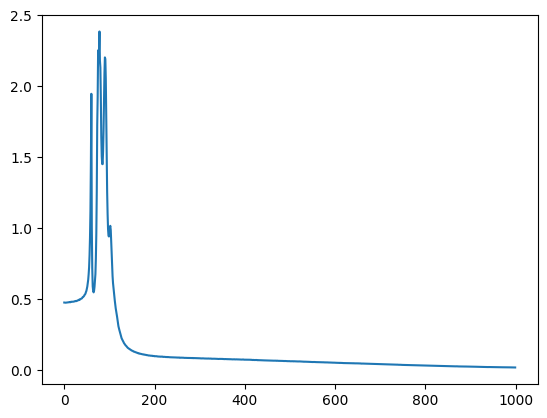

In [75]:
plt.plot(losses)

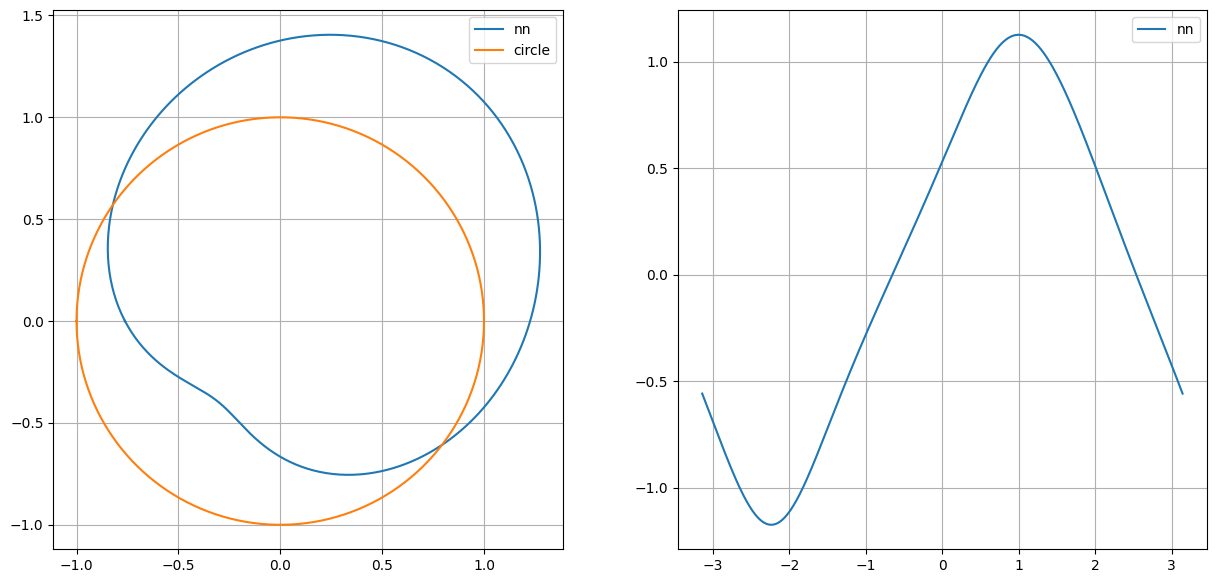

In [76]:
def display_solution_with_fit(model):
    theta = torch.linspace(-np.pi, np.pi, 500, requires_grad = True)
    x1, x2 = torch.cos(theta), torch.sin(theta)
    g = model(x1, x2).detach()
    max_g = 2*torch.max(torch.abs(g))
    #best_g = sol(theta, theta0)
    #max_best_g = 2*torch.max(torch.abs(best_g))
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].plot((torch.cos(theta)*(1+g/max_g)).detach().cpu().numpy(), (torch.sin(theta)*(1+g/max_g)).detach().cpu().numpy(), label='nn')
    #ax[0].plot((torch.cos(theta)*(1+best_g/max_best_g)).detach().cpu().numpy(), (torch.sin(theta)*(1+best_g/max_best_g)).detach().cpu().numpy(), linestyle='dashed', label='best_fit')
    ax[0].plot(torch.cos(theta).detach().cpu().numpy(), torch.sin(theta).detach().cpu().numpy(), label='circle')
    #ax[0].arrow(0,0, (torch.cos(-theta0)*.8).detach().cpu().numpy(), (torch.sin(-theta0)*0.8).detach().cpu().numpy(), color="red", head_width=.05)
    ax[0].legend()
    ax[0].grid()
    ax[0].set_aspect("equal")
    ax[1].plot(theta.detach().cpu().numpy(), g.detach().cpu().numpy(), label='nn')
    #ax[1].plot(theta.detach().cpu().numpy(), best_g.detach().cpu().numpy(), linestyle='dashed', label='best_fit')
    ax[1].legend()
    ax[1].grid()
    #plt.suptitle(f"L2 norm between y_theta0 and y_hat: {l2_norm(g-sol(theta,theta0)):.5e}")
    plt.show()
display_solution_with_fit(model)

We can implement a FD difference whose estimation of error is known, and show that our PINN is at most at this distance.